In [1]:
!pip install xgboost scikit-learn pandas matplotlib seaborn joblib

In [2]:
# Run this once if xgboost not installed
# !pip install xgboost scikit-learn pandas matplotlib seaborn joblib

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib




In [3]:

# Ensure a compatible xgboost version is installed to avoid:
# ImportError: cannot import name 'PANDAS_INSTALLED' from 'xgboost.compat'
%pip install -q xgboost==1.7.6

import xgboost as xgb
from xgboost import XGBClassifier, plot_importance


Note: you may need to restart the kernel to use updated packages.


In [4]:
# Load dataset
df = pd.read_csv("train.csv")
df["catalog_content"] = df["catalog_content"].fillna("").astype(str)

# Create categorical target: price_class (Low / Medium / High)
df["price_class"] = pd.qcut(df["price"], q=3, labels=["Low", "Medium", "High"])
print("Target distribution:\n", df["price_class"].value_counts())


Target distribution:
 price_class
Low       25393
High      24952
Medium    24655
Name: count, dtype: int64


In [5]:
# Extract numeric text-based features
def make_features(s):
    s = s.fillna("").astype(str)
    return pd.DataFrame({
        "text_length": s.str.len(),
        "word_count": s.str.split().map(len),
        "digits": s.str.count(r"\d"),
        "commas": s.str.count(","),
        "periods": s.str.count("\.")
    })

X = make_features(df["catalog_content"])
X["sample_id"] = df["sample_id"].astype(float)

y = df["price_class"]

print("Feature sample:\n", X.head())


<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/hg/6k2xrn0x1hxd4zlz_g32w19h0000gn/T/ipykernel_34669/3852984597.py:9: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  "periods": s.str.count("\.")


Feature sample:
    text_length  word_count  digits  commas  periods  sample_id
0           91          18       6       1        1    33127.0
1          511          80      17       4        1   198967.0
2          328          59      12       2        2   261251.0
3         1318         211      17      14        9    55858.0
4          155          28      13       2        5   292686.0


In [6]:
# Encode class labels into numeric values
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train shape:", X_train.shape, "Val shape:", X_val.shape)


Train shape: (60000, 6) Val shape: (15000, 6)


In [7]:
# Train XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="multi:softmax",  # for multi-class classification
    num_class=3,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)


,objective,'multi:softmax'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


✅ Accuracy: 48.99%

Classification Report:
               precision    recall  f1-score   support

        High       0.56      0.43      0.49      4990
         Low       0.48      0.70      0.57      5079
      Medium       0.44      0.33      0.37      4931

    accuracy                           0.49     15000
   macro avg       0.49      0.49      0.48     15000
weighted avg       0.49      0.49      0.48     15000



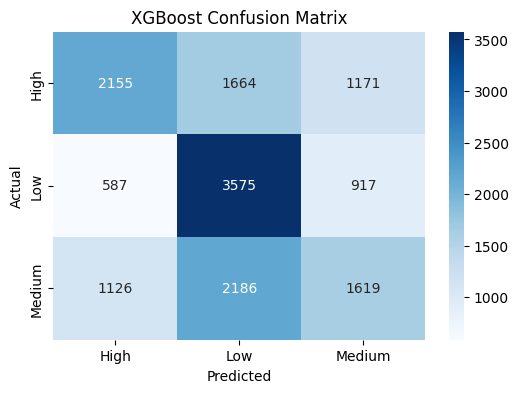

In [8]:
# Predict
y_pred = xgb_model.predict(X_val)

# Decode predicted classes
y_val_decoded = le.inverse_transform(y_val)
y_pred_decoded = le.inverse_transform(y_pred)

# Evaluation
acc = accuracy_score(y_val_decoded, y_pred_decoded)
print(f"✅ Accuracy: {acc*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_val_decoded, y_pred_decoded))

# Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val_decoded, y_pred_decoded),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


<Figure size 800x500 with 0 Axes>

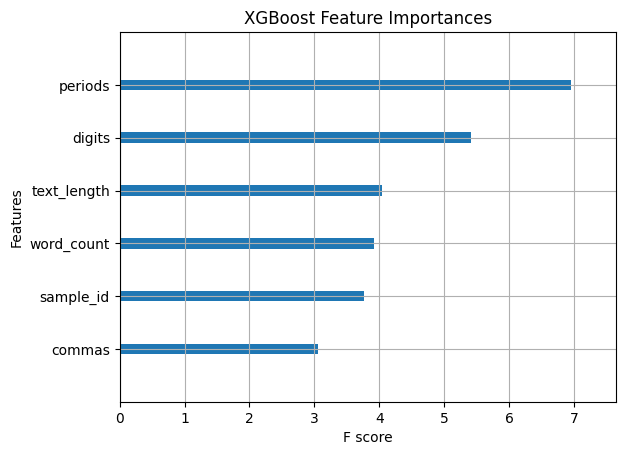

In [9]:
# Plot feature importance
plt.figure(figsize=(8,5))
plot_importance(xgb_model, importance_type="gain", show_values=False)
plt.title("XGBoost Feature Importances")
plt.show()


In [10]:
# Load test data and prepare features
test_df = pd.read_csv("test.csv")
test_df["catalog_content"] = test_df["catalog_content"].fillna("").astype(str)

X_test = make_features(test_df["catalog_content"])
X_test["sample_id"] = test_df["sample_id"].astype(float)

# Predict price category
test_pred = xgb_model.predict(X_test)
test_df["predicted_price_class"] = le.inverse_transform(test_pred)

# Save predictions
test_df.to_csv("test_xgboost_predictions.csv", index=False)
print("💾 Saved predictions to 'test_xgboost_predictions.csv'")


💾 Saved predictions to 'test_xgboost_predictions.csv'


In [11]:
# Load test data and prepare features
test_df = pd.read_csv("test.csv")
test_df["catalog_content"] = test_df["catalog_content"].fillna("").astype(str)

X_test = make_features(test_df["catalog_content"])
X_test["sample_id"] = test_df["sample_id"].astype(float)

# Predict price category
test_pred = xgb_model.predict(X_test)
test_df["predicted_price_class"] = le.inverse_transform(test_pred)

# Save predictions
test_df.to_csv("test_xgboost_predictions.csv", index=False)
print("💾 Saved predictions to 'test_xgboost_predictions.csv'")


💾 Saved predictions to 'test_xgboost_predictions.csv'


In [12]:
joblib.dump(xgb_model, "models/xgboost_price_classifier.joblib")
print("💾 XGBoost model saved as 'models/xgboost_price_classifier.joblib'")


💾 XGBoost model saved as 'models/xgboost_price_classifier.joblib'
